# Day 6 — Train-only 제한적 모델 개선과 앱 구조 유사도

이 노트북은 기존 Day 3 고정 test를 모델 선택에 다시 사용하지 않고, **Train 1,572개만** 이용해 정확히 세 가지 Random Forest 후보를 같은 5-fold 교차검증으로 비교합니다.

오늘의 핵심 질문은 단순 Accuracy가 아니라 다음입니다.

- BBB-를 올바르게 찾는 **Specificity**가 높아지는가?
- 두 클래스를 균형 있게 보는 **Balanced Accuracy**와 **MCC**가 높아지는가?
- 그 대신 BBB+ **Sensitivity**가 얼마나 감소하는가?

기존 Day 1~5 노트북, 결과 그림·CSV와 앱 모델 파일은 덮어쓰거나 삭제하지 않습니다. 새 후보는 Train CV에서만 비교하므로 기존 앱 모델을 자동 교체하지 않습니다.


## 1. 실행 환경과 기존 파일 해시 기록

**입력:** 프로젝트 폴더, 설치된 패키지와 Day 1~5의 노트북·결과·기존 모델 파일입니다.  
**처리:** 프로젝트 위치를 찾고 각 기존 파일의 SHA-256을 계산합니다. SHA-256은 파일 내용이 한 글자라도 바뀌면 달라지는 내용 지문입니다.  
**출력:** 환경 버전과 `results/day6_preexisting_file_sha256.csv`입니다. 이 표는 마지막 셀에서 기존 파일이 그대로인지 다시 확인할 때 사용합니다.


In [1]:
from pathlib import Path
import hashlib
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
WORK_DIR = PROJECT_ROOT / "work"
RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
WORK_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(WORK_DIR / "matplotlib-cache"))

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit
import seaborn as sns
import sklearn
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

preexisting_paths = sorted(
    list((PROJECT_ROOT / "notebooks").glob("0[1-5]_*.ipynb"))
    + list((PROJECT_ROOT / "results").glob("day[1-5]_*"))
    + [PROJECT_ROOT / "models" / "bbbp_random_forest.joblib"]
)
preexisting_hashes = pd.DataFrame(
    [
        {
            "path": path.relative_to(PROJECT_ROOT).as_posix(),
            "bytes": path.stat().st_size,
            "sha256": file_sha256(path),
        }
        for path in preexisting_paths
    ]
)
hash_manifest_path = RESULTS_DIR / "day6_preexisting_file_sha256.csv"
preexisting_hashes.to_csv(hash_manifest_path, index=False, encoding="utf-8")

versions = pd.Series(
    {
        "Python": sys.version.split()[0],
        "NumPy": np.__version__,
        "pandas": pd.__version__,
        "RDKit": rdkit.__version__,
        "scikit-learn": sklearn.__version__,
        "Matplotlib": matplotlib.__version__,
        "seaborn": sns.__version__,
        "joblib": joblib.__version__,
    },
    name="version",
)
display(versions.to_frame())
print(f"기존 파일 해시 기록: {len(preexisting_hashes)}개")
display(preexisting_hashes)


,version
Python,3.12.13
NumPy,2.5.2
pandas,3.0.5
RDKit,2026.03.5
scikit-learn,1.9.0
Matplotlib,3.11.1
seaborn,0.13.2
joblib,1.5.3


기존 파일 해시 기록: 26개


,path,bytes,sha256
0,models/bbbp_random_forest.joblib,2343942,e0e6bd289cba4d98930106ca40b9ee38de505c9c9dd0775b5eee31673c94ec6c
1,notebooks/01_data_exploration.ipynb,264371,2f17b65d2ed2f044dec8daf1ca32ce771d46e697db16f5fa60bfe832a26db91d
2,notebooks/02_feature_engineering.ipynb,271895,d8ee4f0e930a61e51344f5735ca241c410ed025ab4f750ff141173d7619fe52f
3,notebooks/03_model_training.ipynb,156575,b2df520741c3405ef82791d8f593706bafd3e96c068b307ba3daac9d2f569169
4,notebooks/04_model_validation_and_error_analysis.ipynb,517473,93e240431f99dd83e665346449f778f40da8c4581eff50009b43cfe268d0fc68
5,results/day1_bbb_examples.png,76492,89b266d3b49f55fb8ddfc2b9c635aaa83ccbd2528fd77d7d59fc609abf7cd449
6,results/day1_data_summary.csv,175,46b6b5844f8bb3209b440a67716810c429fc7c20cf5a74457ce1f683ce549ee8
7,results/day1_failed_smiles.csv,1318,39e9a2f04e253d3bcf0f6bfa620a0cc0672817da81ebc4dfc9b762af6f246814
8,results/day2_conflicting_labels.csv,3031,3c0573d88cc96bcd2809d6292edd9923297a4672622572535d225636be21a518
9,results/day2_data_cleaning_summary.csv,495,f2ab701eb45dd8e3a6cdb1725261501e520a848bb4e600e3fd67d07af064d822


## 2. 기존 앱 모델과 재현 설정 확인

**입력:** `models/bbbp_random_forest.joblib`과 Day 3 재현 스크립트에 고정된 설정입니다.  
**처리:** 모델의 SHA-256, Morgan 설정, 임계값, Random Forest 파라미터, Train/Test 행 수와 Day 3 평가 기록을 읽습니다.  
**출력:** 기존 모델 bundle의 핵심 정보입니다. 이 셀은 모델을 다시 학습하거나 test 예측을 하지 않습니다.


In [2]:
from scripts.build_model import (
    EXPECTED_CONFUSION,
    RANDOM_STATE,
    RF_PARAMETERS,
    TEST_SIZE,
    THRESHOLD,
    load_and_clean_bbbp,
    stable_hash,
)
from src.features import (
    DESCRIPTOR_NAMES,
    MORGAN_FP_SIZE,
    MORGAN_RADIUS,
    molecules_to_descriptor_matrix,
    molecules_to_morgan_matrix,
)
from src.predict import DEFAULT_MODEL_PATH, load_model_bundle
from src.similarity import (
    DEFAULT_SIMILARITY_REFERENCE_PATH,
    create_similarity_reference,
    find_most_similar_train,
    load_similarity_reference,
    save_similarity_reference,
)

EXPECTED_MODEL_SHA256 = "e0e6bd289cba4d98930106ca40b9ee38de505c9c9dd0775b5eee31673c94ec6c"
EXPECTED_TRAIN_SOURCE_HASH = "7a21d868677d85e44b64087819ec59c7a4979545193463ae36bcd97a11c5a38a"
EXPECTED_TEST_SOURCE_HASH = "a2cafded08e638f85b2ae931d49de5f054bf12e7f640cbac7c9e980ffe6fe699"

app_bundle = load_model_bundle(DEFAULT_MODEL_PATH)
assert file_sha256(DEFAULT_MODEL_PATH) == EXPECTED_MODEL_SHA256
assert app_bundle["fingerprint"] == {
    "radius": 2,
    "fp_size": 2048,
    "generator": "RDKit FingerprintGenerator",
    "is_bit_vector": True,
}
assert app_bundle["threshold"] == THRESHOLD == 0.5
assert app_bundle["training"]["train_molecules"] == 1572
assert app_bundle["training"]["test_molecules"] == 393
assert app_bundle["reproduction"]["confusion_matrix"] == EXPECTED_CONFUSION.tolist()

bundle_check = pd.DataFrame(
    [
        {"항목": "모델 SHA-256", "값": file_sha256(DEFAULT_MODEL_PATH)},
        {"항목": "Morgan 설정", "값": f"radius={MORGAN_RADIUS}, fpSize={MORGAN_FP_SIZE}"},
        {"항목": "threshold", "값": THRESHOLD},
        {"항목": "Train/Test", "값": "1,572 / 393"},
        {"항목": "Day 3 Test ROC-AUC(기존 기록)", "값": app_bundle["reproduction"]["metrics"]["roc_auc"]},
        {"항목": "Day 3 confusion matrix(기존 기록)", "값": str(app_bundle["reproduction"]["confusion_matrix"])},
    ]
)
display(bundle_check)
display(pd.Series(app_bundle["random_forest_parameters"], name="기존 RF 파라미터").to_frame())


,항목,값
0,모델 SHA-256,e0e6bd289cba4d98930106ca40b9ee38de505c9c9dd0775b5eee31673c94ec6c
1,Morgan 설정,"radius=2, fpSize=2048"
2,threshold,0.5
3,Train/Test,"1,572 / 393"
4,Day 3 Test ROC-AUC(기존 기록),0.895986
5,Day 3 confusion matrix(기존 기록),"[[53, 40], [6, 294]]"


,기존 RF 파라미터
bootstrap,True
ccp_alpha,0.0
class_weight,None
criterion,gini
max_depth,None
max_features,sqrt
max_leaf_nodes,None
max_samples,None
min_impurity_decrease,0.0
min_samples_leaf,1


## 3. Day 3과 같은 Train/Test를 재현하되 Test는 봉인

**입력:** Day 1~5와 같은 DeepChem 공식 BBBP URL의 원본 데이터입니다. 원본 CSV를 저장소에 복사하지 않고 메모리에서 읽습니다.  
**처리:** Day 2와 같은 파싱·canonical SMILES·중복·충돌 처리 후 Day 3과 같은 stratified 80:20 분할을 재현합니다.  
**출력:** Train 1,572개와 봉인된 Test 393개의 개수·라벨 분포·행 순서 해시입니다. 이후 후보 비교에는 Train만 사용합니다.


In [3]:
final_model_df = load_and_clean_bbbp()
train_df, sealed_test_df = train_test_split(
    final_model_df,
    test_size=TEST_SIZE,
    stratify=final_model_df["p_np"],
    random_state=RANDOM_STATE,
)
train_df = train_df.reset_index(drop=True)
sealed_test_df = sealed_test_df.reset_index(drop=True)
y_train = train_df["p_np"].to_numpy()
train_source_ids = train_df["source_index"].to_numpy()
sealed_test_source_ids = set(sealed_test_df["source_index"].tolist())

assert len(final_model_df) == 1965
assert len(train_df) == 1572 and len(sealed_test_df) == 393
assert train_df["p_np"].value_counts().sort_index().to_dict() == {0: 372, 1: 1200}
assert sealed_test_df["p_np"].value_counts().sort_index().to_dict() == {0: 93, 1: 300}
assert set(train_source_ids).isdisjoint(sealed_test_source_ids)
assert stable_hash(train_df["source_index"]) == EXPECTED_TRAIN_SOURCE_HASH
assert stable_hash(sealed_test_df["source_index"]) == EXPECTED_TEST_SOURCE_HASH

split_check = pd.DataFrame(
    [
        {"구분": "Train", "행 수": len(train_df), "BBB-": int((y_train == 0).sum()), "BBB+": int((y_train == 1).sum())},
        {
            "구분": "봉인 Test",
            "행 수": len(sealed_test_df),
            "BBB-": int((sealed_test_df["p_np"] == 0).sum()),
            "BBB+": int((sealed_test_df["p_np"] == 1).sum()),
        },
    ]
)
display(split_check)
print("후보 비교용 데이터는 Train 1,572개뿐입니다. Test 393개는 이후 특징 생성·예측에 사용하지 않습니다.")


,구분,행 수,BBB-,BBB+
0,Train,1572,372,1200
1,봉인 Test,393,93,300


후보 비교용 데이터는 Train 1,572개뿐입니다. Test 393개는 이후 특징 생성·예측에 사용하지 않습니다.


## 4. 비교할 세 후보와 특징 행렬 고정

**입력:** Train 분자의 RDKit 객체입니다.  
**처리:** 모든 후보에 같은 Morgan fingerprint(`radius=2`, 2,048 bit)를 만듭니다. 후보 C만 그 뒤에 Day 2 순서의 descriptor 8개를 붙입니다. Random Forest에는 descriptor scaling을 하지 않습니다.  
**출력:** 후보 A/B는 `(1572, 2048)`, 후보 C는 `(1572, 2056)`입니다. 모델 설정 차이도 지정한 범위를 벗어나지 않는지 검사합니다.


In [4]:
X_train_morgan = molecules_to_morgan_matrix(train_df["mol"].tolist())
X_train_descriptors = molecules_to_descriptor_matrix(train_df["mol"].tolist())
X_train_combined = np.column_stack([X_train_morgan, X_train_descriptors])

assert DESCRIPTOR_NAMES == [
    "MolWt", "MolLogP", "TPSA", "NumHDonors",
    "NumHAcceptors", "NumRotatableBonds", "RingCount", "FractionCSP3",
]
assert X_train_morgan.shape == (1572, 2048)
assert X_train_descriptors.shape == (1572, 8)
assert X_train_combined.shape == (1572, 2056)
assert np.array_equal(X_train_combined[:, :2048], X_train_morgan)
assert np.array_equal(X_train_combined[:, 2048:], X_train_descriptors)
assert np.isfinite(X_train_descriptors).all()
assert set(np.unique(X_train_morgan)).issubset({0, 1})

candidate_models = {
    "A: Existing RF": RandomForestClassifier(**RF_PARAMETERS),
    "B: Balanced RF": RandomForestClassifier(**RF_PARAMETERS, class_weight="balanced"),
    "C: Morgan + descriptors RF": RandomForestClassifier(**RF_PARAMETERS),
}
candidate_features = {
    "A: Existing RF": X_train_morgan,
    "B: Balanced RF": X_train_morgan,
    "C: Morgan + descriptors RF": X_train_combined,
}
feature_descriptions = {
    "A: Existing RF": "Morgan 2048 bits",
    "B: Balanced RF": "Morgan 2048 bits",
    "C: Morgan + descriptors RF": "Morgan 2048 bits + 8 descriptors",
}

params_a = candidate_models["A: Existing RF"].get_params()
params_b = candidate_models["B: Balanced RF"].get_params()
params_c = candidate_models["C: Morgan + descriptors RF"].get_params()
assert {key for key in params_a if params_a[key] != params_b[key]} == {"class_weight"}
assert params_a == params_c
assert params_a["class_weight"] is None and params_b["class_weight"] == "balanced"
assert params_a["n_estimators"] == 300 and params_a["max_depth"] is None
assert THRESHOLD == 0.5

feature_check = pd.DataFrame(
    [
        {
            "후보": name,
            "특징": feature_descriptions[name],
            "shape": str(candidate_features[name].shape),
            "class_weight": model.get_params()["class_weight"],
            "descriptor scaling": "사용 안 함",
        }
        for name, model in candidate_models.items()
    ]
)
display(feature_check)


,후보,특징,shape,class_weight,descriptor scaling
0,A: Existing RF,Morgan 2048 bits,"(1572, 2048)",NaN,사용 안 함
1,B: Balanced RF,Morgan 2048 bits,"(1572, 2048)",balanced,사용 안 함
2,C: Morgan + descriptors RF,Morgan 2048 bits + 8 descriptors,"(1572, 2056)",NaN,사용 안 함


## 5. 결과를 보기 전에 개선 후보 판정 기준 고정

아래 기준은 교차검증 결과를 계산하기 **전에** 고정합니다.

후보 B 또는 C가 기존 후보 A보다 다음을 모두 만족할 때만 **개선 후보**라고 부릅니다.

1. 평균 Balanced Accuracy가 더 높다.
2. 평균 MCC가 더 높다.
3. 평균 Specificity가 더 높다.
4. 평균 Sensitivity가 0.95 이상이다.

두 후보가 모두 통과하면 평균 Balanced Accuracy가 높은 후보를 우선하고, 그 차이가 매우 작으면 MCC를 함께 봅니다. Fold별 변동도 별도로 기록합니다. 이 비교는 통계적 유의성 검정이 아니며, CV 평균이 높아도 새로운 Test 성능 향상을 보장하지 않습니다.


## 6. 모든 후보가 공유할 Train-only 5-fold 만들기

**입력:** Train 1,572개의 라벨과 원본 행 번호입니다.  
**처리:** `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`를 한 번만 만들고 세 후보가 같은 위치 인덱스를 재사용합니다.  
**출력:** Fold별 학습·검증 크기와 클래스 수입니다. 각 Train 분자는 검증 fold에 정확히 한 번 들어가며 봉인 Test 행은 0개인지 확인합니다.


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_splits = list(cv.split(np.zeros(len(train_df)), y_train))
validation_counts = np.zeros(len(train_df), dtype=int)
fold_rows = []

for fold_number, (fold_train_positions, fold_valid_positions) in enumerate(fold_splits, start=1):
    fold_train_sources = set(train_source_ids[fold_train_positions].tolist())
    fold_valid_sources = set(train_source_ids[fold_valid_positions].tolist())
    assert fold_train_sources.isdisjoint(fold_valid_sources)
    assert fold_train_sources.isdisjoint(sealed_test_source_ids)
    assert fold_valid_sources.isdisjoint(sealed_test_source_ids)
    validation_counts[fold_valid_positions] += 1
    fold_rows.append(
        {
            "fold": fold_number,
            "train_rows": len(fold_train_positions),
            "validation_rows": len(fold_valid_positions),
            "validation_BBB-": int((y_train[fold_valid_positions] == 0).sum()),
            "validation_BBB+": int((y_train[fold_valid_positions] == 1).sum()),
        }
    )

assert len(fold_splits) == 5
assert np.all(validation_counts == 1)
display(pd.DataFrame(fold_rows))
print("검증 통과: 세 후보가 공유할 동일 fold이며, 봉인 Test 인덱스는 한 번도 포함되지 않습니다.")


,fold,train_rows,validation_rows,validation_BBB-,validation_BBB+
0,1,1257,315,75,240
1,2,1257,315,75,240
2,3,1258,314,74,240
3,4,1258,314,74,240
4,5,1258,314,74,240


검증 통과: 세 후보가 공유할 동일 fold이며, 봉인 Test 인덱스는 한 번도 포함되지 않습니다.


## 7. 세 후보의 동일 5-fold CV와 OOF 예측

**입력:** 고정한 세 후보, 각 후보의 Train 특징, 같은 다섯 fold입니다.  
**처리:** Fold마다 새 Random Forest를 fold-train으로만 학습하고 fold-validation을 예측합니다. 결정 기준은 모두 0.5입니다. 각 분자의 OOF 예측은 그 분자를 학습하지 않은 모델에서만 받습니다.  
**출력:** Fold별 8개 지표 CSV, Fold별 confusion count CSV와 후보별 OOF 예측입니다.


In [6]:
metric_rows = []
confusion_rows = []
oof_predictions = {
    name: np.full(len(train_df), -1, dtype=int) for name in candidate_models
}
oof_probabilities = {
    name: np.full(len(train_df), np.nan, dtype=float) for name in candidate_models
}
oof_assignment_counts = {
    name: np.zeros(len(train_df), dtype=int) for name in candidate_models
}
validation_signatures = {name: [] for name in candidate_models}

for candidate_name, base_model in candidate_models.items():
    X_candidate = candidate_features[candidate_name]
    for fold_number, (fold_train_positions, fold_valid_positions) in enumerate(fold_splits, start=1):
        assert set(fold_train_positions).isdisjoint(set(fold_valid_positions))
        fold_model = clone(base_model)
        fold_model.fit(X_candidate[fold_train_positions], y_train[fold_train_positions])

        positive_column = int(np.where(fold_model.classes_ == 1)[0][0])
        probability = fold_model.predict_proba(X_candidate[fold_valid_positions])[:, positive_column]
        prediction = (probability > THRESHOLD).astype(int)
        assert np.array_equal(prediction, fold_model.predict(X_candidate[fold_valid_positions]))

        y_valid = y_train[fold_valid_positions]
        tn, fp, fn, tp = confusion_matrix(y_valid, prediction, labels=[0, 1]).ravel()
        metric_rows.append(
            {
                "candidate": candidate_name,
                "feature_set": feature_descriptions[candidate_name],
                "fold": fold_number,
                "train_rows": len(fold_train_positions),
                "validation_rows": len(fold_valid_positions),
                "threshold": THRESHOLD,
                "accuracy": accuracy_score(y_valid, prediction),
                "f1_score": f1_score(y_valid, prediction, pos_label=1, zero_division=0),
                "roc_auc": roc_auc_score(y_valid, probability),
                "pr_auc": average_precision_score(y_valid, probability),
                "balanced_accuracy": balanced_accuracy_score(y_valid, prediction),
                "mcc": matthews_corrcoef(y_valid, prediction),
                "sensitivity": recall_score(y_valid, prediction, pos_label=1, zero_division=0),
                "specificity": recall_score(y_valid, prediction, pos_label=0, zero_division=0),
            }
        )
        confusion_rows.append(
            {
                "candidate": candidate_name,
                "fold": fold_number,
                "tn": int(tn),
                "fp": int(fp),
                "fn": int(fn),
                "tp": int(tp),
            }
        )
        oof_predictions[candidate_name][fold_valid_positions] = prediction
        oof_probabilities[candidate_name][fold_valid_positions] = probability
        oof_assignment_counts[candidate_name][fold_valid_positions] += 1
        validation_signatures[candidate_name].append(
            stable_hash(sorted(train_source_ids[fold_valid_positions].tolist()))
        )

reference_signatures = validation_signatures["A: Existing RF"]
for candidate_name in candidate_models:
    assert validation_signatures[candidate_name] == reference_signatures
    assert np.all(oof_assignment_counts[candidate_name] == 1)
    assert np.all(oof_predictions[candidate_name] >= 0)
    assert np.isfinite(oof_probabilities[candidate_name]).all()

cv_fold_metrics = pd.DataFrame(metric_rows)
cv_confusion_counts = pd.DataFrame(confusion_rows)
cv_fold_path = RESULTS_DIR / "day6_candidate_cv_fold_metrics.csv"
cv_confusion_path = RESULTS_DIR / "day6_candidate_cv_confusion_counts.csv"
cv_fold_metrics.to_csv(cv_fold_path, index=False, encoding="utf-8", float_format="%.6f")
cv_confusion_counts.to_csv(cv_confusion_path, index=False, encoding="utf-8")
display(cv_fold_metrics.round(4))
display(cv_confusion_counts)


,candidate,feature_set,fold,train_rows,validation_rows,threshold,accuracy,f1_score,roc_auc,pr_auc,balanced_accuracy,mcc,sensitivity,specificity
0,A: Existing RF,Morgan 2048 bits,1,1257,315,0.5,0.8667,0.9170,0.9096,0.9656,0.7567,0.6032,0.9667,0.5467
1,A: Existing RF,Morgan 2048 bits,2,1257,315,0.5,0.9016,0.9389,0.9638,0.9876,0.8025,0.7170,0.9917,0.6133
2,A: Existing RF,Morgan 2048 bits,3,1258,314,0.5,0.8790,0.9243,0.9028,0.9616,0.7806,0.6408,0.9667,0.5946
3,A: Existing RF,Morgan 2048 bits,4,1258,314,0.5,0.9204,0.9491,0.9526,0.9831,0.8638,0.7711,0.9708,0.7568
4,A: Existing RF,Morgan 2048 bits,5,1258,314,0.5,0.8790,0.9249,0.8895,0.9504,0.7713,0.6399,0.9750,0.5676
5,B: Balanced RF,Morgan 2048 bits,1,1257,315,0.5,0.8794,0.9231,0.9118,0.9686,0.8017,0.6503,0.9500,0.6533
6,B: Balanced RF,Morgan 2048 bits,2,1257,315,0.5,0.9333,0.9569,0.9662,0.9883,0.8921,0.8118,0.9708,0.8133
7,B: Balanced RF,Morgan 2048 bits,3,1258,314,0.5,0.8726,0.9180,0.9153,0.9696,0.8045,0.6344,0.9333,0.6757
8,B: Balanced RF,Morgan 2048 bits,4,1258,314,0.5,0.9236,0.9500,0.9554,0.9838,0.8939,0.7878,0.9500,0.8378
9,B: Balanced RF,Morgan 2048 bits,5,1258,314,0.5,0.8822,0.9256,0.8944,0.9566,0.7967,0.6535,0.9583,0.6351


,candidate,fold,tn,fp,fn,tp
0,A: Existing RF,1,41,34,8,232
1,A: Existing RF,2,46,29,2,238
2,A: Existing RF,3,44,30,8,232
3,A: Existing RF,4,56,18,7,233
4,A: Existing RF,5,42,32,6,234
5,B: Balanced RF,1,49,26,12,228
6,B: Balanced RF,2,61,14,7,233
7,B: Balanced RF,3,50,24,16,224
8,B: Balanced RF,4,62,12,12,228
9,B: Balanced RF,5,47,27,10,230


## 8. CV 평균·변동과 사전 기준 판정

**입력:** 세 후보 × 다섯 fold의 지표입니다.  
**처리:** 각 지표의 평균, 표준편차, 최솟값, 최댓값을 계산합니다. 그 다음에만 앞에서 고정한 네 조건을 적용합니다.  
**출력:** `results/day6_candidate_cv_summary.csv`와 개선 후보 판정표입니다. Accuracy나 F1 하나만으로 판정하지 않습니다.


In [7]:
CV_METRICS = [
    "accuracy",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "balanced_accuracy",
    "mcc",
    "sensitivity",
    "specificity",
]
summary_rows = []
for candidate_name in candidate_models:
    candidate_fold_rows = cv_fold_metrics.loc[cv_fold_metrics["candidate"] == candidate_name]
    for metric in CV_METRICS:
        values = candidate_fold_rows[metric]
        summary_rows.append(
            {
                "candidate": candidate_name,
                "feature_set": feature_descriptions[candidate_name],
                "metric": metric,
                "mean": values.mean(),
                "std": values.std(ddof=1),
                "min": values.min(),
                "max": values.max(),
            }
        )

cv_summary = pd.DataFrame(summary_rows)
cv_summary_path = RESULTS_DIR / "day6_candidate_cv_summary.csv"
cv_summary.to_csv(cv_summary_path, index=False, encoding="utf-8", float_format="%.6f")

summary_wide = cv_summary.pivot(index="candidate", columns="metric", values="mean")
baseline = summary_wide.loc["A: Existing RF"]
decision_rows = []
for candidate_name in ["B: Balanced RF", "C: Morgan + descriptors RF"]:
    row = summary_wide.loc[candidate_name]
    checks = {
        "Balanced Accuracy > A": bool(row["balanced_accuracy"] > baseline["balanced_accuracy"]),
        "MCC > A": bool(row["mcc"] > baseline["mcc"]),
        "Specificity > A": bool(row["specificity"] > baseline["specificity"]),
        "Sensitivity >= 0.95": bool(row["sensitivity"] >= 0.95),
    }
    decision_rows.append(
        {
            "candidate": candidate_name,
            **checks,
            "meets_all_predefined_criteria": all(checks.values()),
        }
    )
decision_df = pd.DataFrame(decision_rows)
qualified_candidates = decision_df.loc[
    decision_df["meets_all_predefined_criteria"], "candidate"
].tolist()
if qualified_candidates:
    selected_candidate = (
        summary_wide.loc[qualified_candidates]
        .sort_values(["balanced_accuracy", "mcc"], ascending=False)
        .index[0]
    )
else:
    selected_candidate = None

display(cv_summary.round(4))
display(decision_df)
print(
    f"사전 기준을 모두 충족한 개선 후보: {selected_candidate}"
    if selected_candidate
    else "사전 기준을 모두 충족한 개선 후보는 없습니다."
)


,candidate,feature_set,metric,mean,std,min,max
0,A: Existing RF,Morgan 2048 bits,accuracy,0.8893,0.0215,0.8667,0.9204
1,A: Existing RF,Morgan 2048 bits,f1_score,0.9308,0.0129,0.9170,0.9491
2,A: Existing RF,Morgan 2048 bits,roc_auc,0.9237,0.0326,0.8895,0.9638
3,A: Existing RF,Morgan 2048 bits,pr_auc,0.9697,0.0154,0.9504,0.9876
4,A: Existing RF,Morgan 2048 bits,balanced_accuracy,0.7950,0.0419,0.7567,0.8638
5,A: Existing RF,Morgan 2048 bits,mcc,0.6744,0.0681,0.6032,0.7711
6,A: Existing RF,Morgan 2048 bits,sensitivity,0.9742,0.0104,0.9667,0.9917
7,A: Existing RF,Morgan 2048 bits,specificity,0.6158,0.0828,0.5467,0.7568
8,B: Balanced RF,Morgan 2048 bits,accuracy,0.8982,0.0280,0.8726,0.9333
9,B: Balanced RF,Morgan 2048 bits,f1_score,0.9347,0.0175,0.9180,0.9569


,candidate,Balanced Accuracy > A,MCC > A,Specificity > A,Sensitivity >= 0.95,meets_all_predefined_criteria
0,B: Balanced RF,True,True,True,True,True
1,C: Morgan + descriptors RF,True,True,True,True,True


사전 기준을 모두 충족한 개선 후보: B: Balanced RF


## 9. 주요 지표와 Sensitivity–Specificity trade-off 그림

**입력:** 후보별 CV 평균과 표준편차입니다.  
**처리:** 개선 목표 네 지표를 평균±표준편차 막대로 비교하고, Sensitivity와 Specificity의 위치를 한 그래프에 표시합니다.  
**출력:** `day6_candidate_metric_comparison.png`와 `day6_sensitivity_specificity_tradeoff.png`입니다.


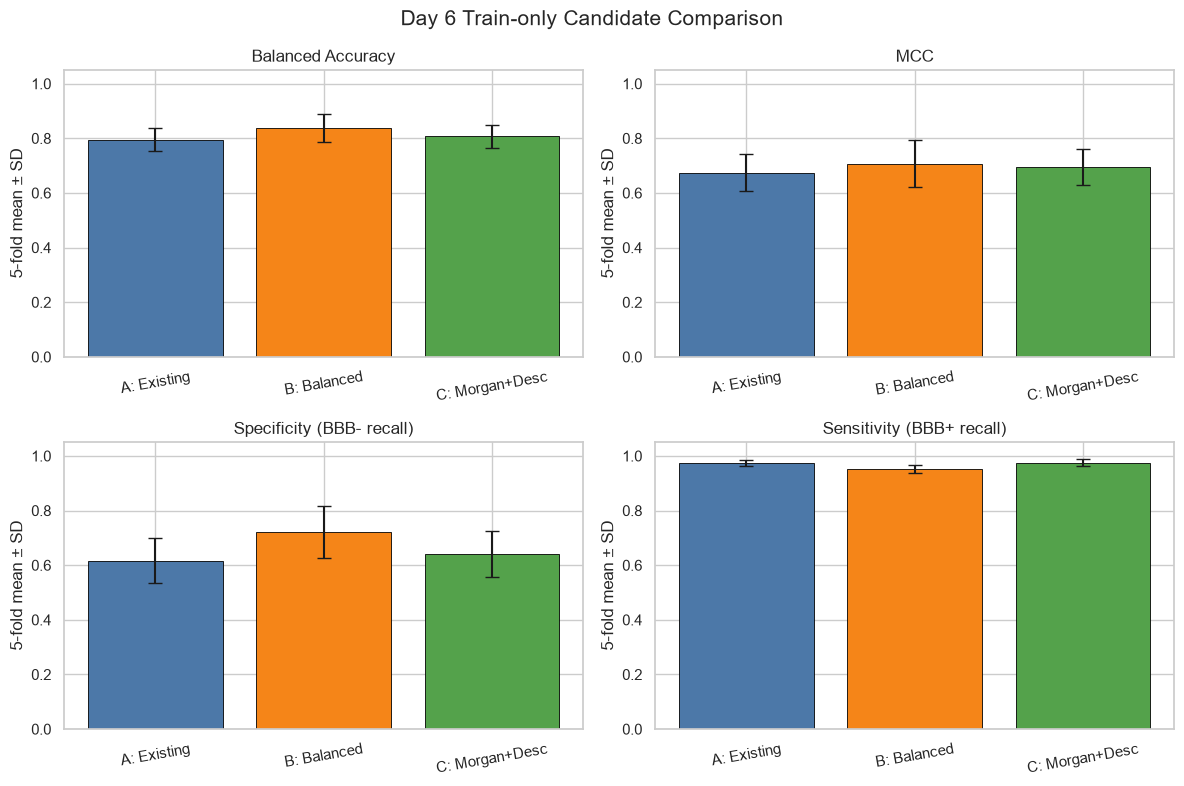

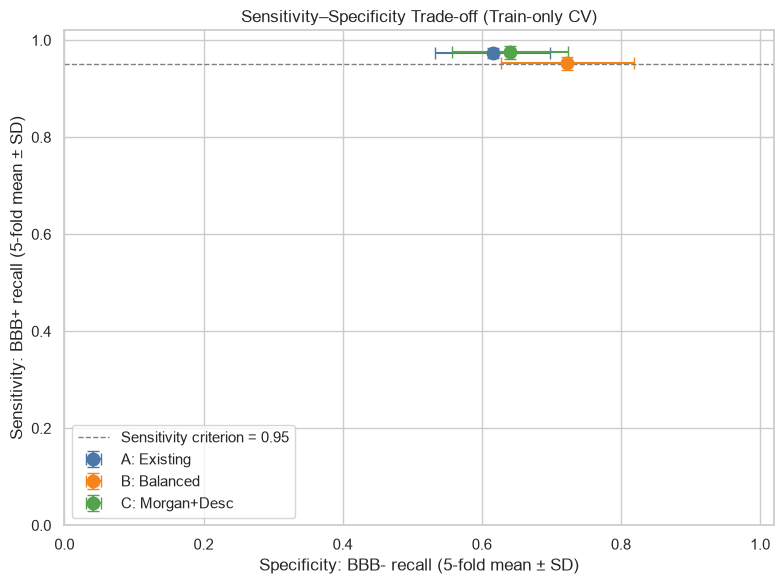

C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day6_candidate_metric_comparison.png
C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\results\day6_sensitivity_specificity_tradeoff.png


In [8]:
candidate_order = list(candidate_models)
short_labels = ["A: Existing", "B: Balanced", "C: Morgan+Desc"]
colors = ["#4C78A8", "#F58518", "#54A24B"]
comparison_metrics = ["balanced_accuracy", "mcc", "specificity", "sensitivity"]
comparison_labels = ["Balanced Accuracy", "MCC", "Specificity (BBB- recall)", "Sensitivity (BBB+ recall)"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, metric, label in zip(axes.ravel(), comparison_metrics, comparison_labels):
    table = (
        cv_summary.loc[cv_summary["metric"] == metric]
        .set_index("candidate")
        .reindex(candidate_order)
    )
    positions = np.arange(len(candidate_order))
    axis.bar(
        positions,
        table["mean"],
        yerr=table["std"],
        capsize=5,
        color=colors,
        edgecolor="black",
        linewidth=0.6,
    )
    axis.set_xticks(positions, short_labels, rotation=10)
    axis.set_ylabel("5-fold mean ± SD")
    axis.set_title(label)
    axis.set_ylim(0, 1.05)

fig.suptitle("Day 6 Train-only Candidate Comparison", fontsize=15)
fig.tight_layout()
metric_comparison_path = RESULTS_DIR / "day6_candidate_metric_comparison.png"
fig.savefig(metric_comparison_path, dpi=200, bbox_inches="tight")
plt.show()

fig, axis = plt.subplots(figsize=(8, 6))
for candidate_name, short_label, color in zip(candidate_order, short_labels, colors):
    candidate_summary = cv_summary.loc[cv_summary["candidate"] == candidate_name].set_index("metric")
    sensitivity_mean = candidate_summary.loc["sensitivity", "mean"]
    specificity_mean = candidate_summary.loc["specificity", "mean"]
    sensitivity_std = candidate_summary.loc["sensitivity", "std"]
    specificity_std = candidate_summary.loc["specificity", "std"]
    axis.errorbar(
        specificity_mean,
        sensitivity_mean,
        xerr=specificity_std,
        yerr=sensitivity_std,
        fmt="o",
        markersize=9,
        capsize=4,
        color=color,
        label=short_label,
    )
axis.axhline(0.95, color="gray", linestyle="--", linewidth=1, label="Sensitivity criterion = 0.95")
axis.set_xlabel("Specificity: BBB- recall (5-fold mean ± SD)")
axis.set_ylabel("Sensitivity: BBB+ recall (5-fold mean ± SD)")
axis.set_xlim(0, 1.02)
axis.set_ylim(0, 1.02)
axis.set_title("Sensitivity–Specificity Trade-off (Train-only CV)")
axis.legend(loc="lower left")
fig.tight_layout()
tradeoff_path = RESULTS_DIR / "day6_sensitivity_specificity_tradeoff.png"
fig.savefig(tradeoff_path, dpi=200, bbox_inches="tight")
plt.show()

print(metric_comparison_path)
print(tradeoff_path)


## 10. Train OOF confusion matrix와 오류 변화

**입력:** 각 Train 분자가 자신을 학습하지 않은 fold 모델에서 받은 OOF 예측입니다.  
**처리:** 후보별 TN, FP, FN, TP를 합치고 후보 A와 비교해 FP가 얼마나 줄었고 FN이 얼마나 늘었는지 계산합니다.  
**출력:** `day6_oof_confusion_summary.csv`와 `day6_oof_confusion_matrices.png`입니다. 봉인 Test prediction은 사용하지 않습니다.


,candidate,tn,fp,fn,tp,BBB-_total,BBB-_correct,BBB+_total,BBB+_correct,specificity,sensitivity,balanced_accuracy,mcc,FP_reduction_vs_A,FN_increase_vs_A
0,A: Existing RF,229,143,31,1169,372,229,1200,1169,0.6156,0.9742,0.7949,0.6747,0,0
1,B: Balanced RF,269,103,57,1143,372,269,1200,1143,0.7231,0.9525,0.8378,0.7083,40,26
2,C: Morgan + descriptors RF,238,134,30,1170,372,238,1200,1170,0.6398,0.9750,0.8074,0.6948,9,-1


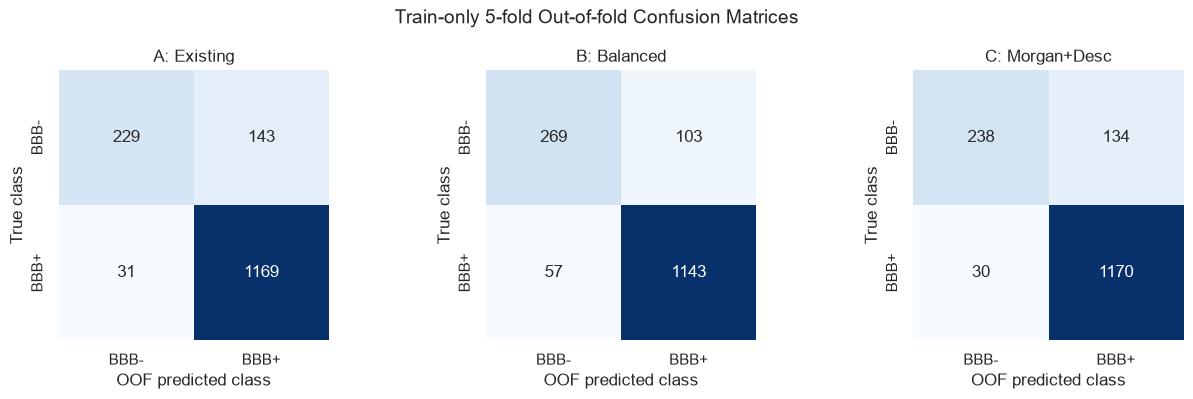

In [9]:
oof_rows = []
for candidate_name in candidate_order:
    prediction = oof_predictions[candidate_name]
    tn, fp, fn, tp = confusion_matrix(y_train, prediction, labels=[0, 1]).ravel()
    oof_rows.append(
        {
            "candidate": candidate_name,
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "BBB-_total": int((y_train == 0).sum()),
            "BBB-_correct": int(tn),
            "BBB+_total": int((y_train == 1).sum()),
            "BBB+_correct": int(tp),
            "specificity": tn / (tn + fp),
            "sensitivity": tp / (tp + fn),
            "balanced_accuracy": ((tn / (tn + fp)) + (tp / (tp + fn))) / 2,
            "mcc": matthews_corrcoef(y_train, prediction),
        }
    )

oof_summary = pd.DataFrame(oof_rows)
baseline_fp = int(oof_summary.loc[oof_summary["candidate"] == "A: Existing RF", "fp"].iloc[0])
baseline_fn = int(oof_summary.loc[oof_summary["candidate"] == "A: Existing RF", "fn"].iloc[0])
oof_summary["FP_reduction_vs_A"] = baseline_fp - oof_summary["fp"]
oof_summary["FN_increase_vs_A"] = oof_summary["fn"] - baseline_fn
oof_summary_path = RESULTS_DIR / "day6_oof_confusion_summary.csv"
oof_summary.to_csv(oof_summary_path, index=False, encoding="utf-8", float_format="%.6f")
display(oof_summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for axis, candidate_name, short_label in zip(axes, candidate_order, short_labels):
    matrix = confusion_matrix(y_train, oof_predictions[candidate_name], labels=[0, 1])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        xticklabels=["BBB-", "BBB+"],
        yticklabels=["BBB-", "BBB+"],
        ax=axis,
    )
    axis.set_title(short_label)
    axis.set_xlabel("OOF predicted class")
    axis.set_ylabel("True class")
fig.suptitle("Train-only 5-fold Out-of-fold Confusion Matrices", fontsize=14)
fig.tight_layout()
oof_plot_path = RESULTS_DIR / "day6_oof_confusion_matrices.png"
fig.savefig(oof_plot_path, dpi=200, bbox_inches="tight")
plt.show()


## 11. 결과를 쉬운 문장으로 정리

**입력:** CV 요약, 사전 기준 판정과 OOF confusion count입니다.  
**처리:** 후보 B/C의 Specificity 증가와 Sensitivity 감소, FP 감소와 FN 증가를 후보 A와 비교합니다.  
**출력:** 실제 숫자에 기반한 한국어 요약입니다. 인과관계나 통계적 유의성, 새 Test 성능 향상을 주장하지 않습니다.


In [10]:
def mean_metric(candidate, metric):
    return float(
        cv_summary.loc[
            (cv_summary["candidate"] == candidate) & (cv_summary["metric"] == metric),
            "mean",
        ].iloc[0]
    )

baseline_oof = oof_summary.set_index("candidate").loc["A: Existing RF"]
sentences = []
for candidate_name in ["B: Balanced RF", "C: Morgan + descriptors RF"]:
    candidate_oof = oof_summary.set_index("candidate").loc[candidate_name]
    qualifies = bool(
        decision_df.loc[
            decision_df["candidate"] == candidate_name,
            "meets_all_predefined_criteria",
        ].iloc[0]
    )
    sentences.append(
        f"- **{candidate_name}**: 평균 Specificity {mean_metric(candidate_name, 'specificity'):.4f} "
        f"(A: {mean_metric('A: Existing RF', 'specificity'):.4f}), 평균 Sensitivity "
        f"{mean_metric(candidate_name, 'sensitivity'):.4f} "
        f"(A: {mean_metric('A: Existing RF', 'sensitivity'):.4f}). "
        f"OOF에서 A보다 FP를 {int(baseline_oof['fp'] - candidate_oof['fp'])}개 줄였고 "
        f"FN은 {int(candidate_oof['fn'] - baseline_oof['fn'])}개 변했습니다. "
        f"사전 기준 전체 충족: {'예' if qualifies else '아니오'}."
    )

conclusion = (
    f"사전 기준을 모두 충족한 후보는 **{selected_candidate}**입니다. "
    "다만 Train-only CV 결과이므로 기존 앱 모델을 교체하지 않습니다."
    if selected_candidate
    else "사전 기준을 모두 충족한 후보는 없습니다. 이번 비교는 성능 개선이 아니라 trade-off로 해석합니다."
)
display(Markdown("\n".join(sentences) + "\n\n" + conclusion))


- **B: Balanced RF**: 평균 Specificity 0.7231 (A: 0.6158), 평균 Sensitivity 0.9525 (A: 0.9742). OOF에서 A보다 FP를 40개 줄였고 FN은 26개 변했습니다. 사전 기준 전체 충족: 예.
- **C: Morgan + descriptors RF**: 평균 Specificity 0.6401 (A: 0.6158), 평균 Sensitivity 0.9750 (A: 0.9742). OOF에서 A보다 FP를 9개 줄였고 FN은 -1개 변했습니다. 사전 기준 전체 충족: 예.

사전 기준을 모두 충족한 후보는 **B: Balanced RF**입니다. 다만 Train-only CV 결과이므로 기존 앱 모델을 교체하지 않습니다.

## 12. Train 내부 구조 유사도 기준과 앱 참조자료

**입력:** 기존 앱 모델과 정확히 같은 Train 1,572개의 Morgan fingerprint입니다.  
**처리:** 각 Train 분자에서 자기 자신을 제외한 가장 가까운 다른 Train 분자의 Tanimoto similarity를 계산합니다. 그 분포의 10번째 백분위수를 경험적 경고 기준으로 정하고, 앱에 필요한 작은 압축 artifact를 저장합니다.  
**출력:** 최소·10백분위·중앙값·90백분위·최대값, 참조파일 크기와 검증 예시입니다. 이 값은 예측 신뢰확률이 아닙니다.


In [11]:
similarity_reference = create_similarity_reference(train_df, X_train_morgan)
similarity_reference["training"]["train_source_order_sha256"] = stable_hash(
    train_df["source_index"]
)
similarity_path = save_similarity_reference(
    similarity_reference,
    DEFAULT_SIMILARITY_REFERENCE_PATH,
)
reloaded_similarity_reference = load_similarity_reference(similarity_path)

nearest_indices = reloaded_similarity_reference["nearest_neighbor_indices"]
nearest_scores = reloaded_similarity_reference["nearest_neighbor_similarities"]
assert np.all(nearest_indices != np.arange(len(train_df)))
assert np.all((nearest_scores >= 0.0) & (nearest_scores <= 1.0))
assert reloaded_similarity_reference["fingerprint"]["radius"] == MORGAN_RADIUS == 2
assert reloaded_similarity_reference["fingerprint"]["fp_size"] == MORGAN_FP_SIZE == 2048
assert reloaded_similarity_reference["training"]["train_source_order_sha256"] == EXPECTED_TRAIN_SOURCE_HASH

first_train_match = find_most_similar_train(
    X_train_morgan[0:1], reloaded_similarity_reference
)
assert first_train_match["maximum_similarity"] == 1.0

similarity_distribution = pd.DataFrame(
    [
        {
            "통계": key,
            "Tanimoto similarity": value,
        }
        for key, value in reloaded_similarity_reference[
            "nearest_neighbor_distribution"
        ].items()
    ]
)
display(similarity_distribution.round(4))
print(f"경고 기준(p10): {reloaded_similarity_reference['warning_threshold']:.4f}")
print(f"Train 포함 분자 입력 시 최대 유사도: {first_train_match['maximum_similarity']:.1f}")
print(f"유사도 참조파일: {similarity_path} ({similarity_path.stat().st_size / 1024 / 1024:.2f} MiB)")
print("주의: Tanimoto similarity와 p10 경고 기준은 예측 확률·정확도·신뢰수준을 보장하지 않습니다.")


,통계,Tanimoto similarity
0,min,0.1081
1,p10,0.3000
2,median,0.5714
3,p90,0.8087
4,max,1.0000


경고 기준(p10): 0.3000
Train 포함 분자 입력 시 최대 유사도: 1.0
유사도 참조파일: C:\Users\NT960XGL-XZ72G\Documents\Codex\2026-08-21\1-bbb-permeability-prediction-moleculenet-bbbp\models\bbbp_train_similarity_reference.joblib (0.20 MiB)
주의: Tanimoto similarity와 p10 경고 기준은 예측 확률·정확도·신뢰수준을 보장하지 않습니다.


## 13. 최종 자동 검증

**입력:** Day 6 표·그림·유사도 artifact, 기존 해시 기록과 모든 검증 변수입니다.  
**처리:** 같은 Train/fold, Test 미사용, 세 후보 제한, 0.5 임계값, OOF 누출 방지, 기존 모델·Day 1~5 파일 불변, CSV 숫자와 필수 파일을 다시 확인합니다.  
**출력:** 통과 항목 표입니다. 모델 후보를 기존 Test에 적용하는 코드는 이 노트북에 없습니다.


In [12]:
required_day6_outputs = [
    hash_manifest_path,
    cv_fold_path,
    cv_summary_path,
    cv_confusion_path,
    metric_comparison_path,
    tradeoff_path,
    oof_summary_path,
    oof_plot_path,
    similarity_path,
]
assert all(path.exists() and path.stat().st_size > 0 for path in required_day6_outputs)
assert len(candidate_models) == 3
assert set(candidate_models) == {
    "A: Existing RF",
    "B: Balanced RF",
    "C: Morgan + descriptors RF",
}
assert all(signatures == reference_signatures for signatures in validation_signatures.values())
assert all(np.all(counts == 1) for counts in oof_assignment_counts.values())
assert set(train_source_ids).isdisjoint(sealed_test_source_ids)
assert cv_fold_metrics["threshold"].eq(0.5).all()
assert len(cv_fold_metrics) == 15
assert len(cv_confusion_counts) == 15
assert len(cv_summary) == 24
assert len(oof_summary) == 3
assert file_sha256(DEFAULT_MODEL_PATH) == EXPECTED_MODEL_SHA256
assert app_bundle["reproduction"]["confusion_matrix"] == [[53, 40], [6, 294]]
assert round(app_bundle["reproduction"]["metrics"]["roc_auc"], 4) == 0.8960
assert not (PROJECT_ROOT / "BBBP.csv").exists()
assert not list(PROJECT_ROOT.glob("**/*fingerprint*.csv"))

current_preexisting_hashes = pd.DataFrame(
    [
        {
            "path": path.relative_to(PROJECT_ROOT).as_posix(),
            "bytes": path.stat().st_size,
            "sha256": file_sha256(path),
        }
        for path in preexisting_paths
    ]
)
pd.testing.assert_frame_equal(preexisting_hashes, current_preexisting_hashes)
pd.testing.assert_frame_equal(
    pd.read_csv(cv_fold_path),
    cv_fold_metrics.round(6),
    check_dtype=False,
)
pd.testing.assert_frame_equal(
    pd.read_csv(cv_confusion_path),
    cv_confusion_counts,
    check_dtype=False,
)
pd.testing.assert_frame_equal(
    pd.read_csv(oof_summary_path),
    oof_summary.round(6),
    check_dtype=False,
)

final_checks = pd.DataFrame(
    {
        "검증 항목": [
            "후보 수와 허용 변경 범위",
            "동일 Train과 동일 5-fold",
            "봉인 Test 인덱스 CV 포함",
            "threshold",
            "OOF 분자별 검증 예측 횟수",
            "기존 앱 모델 SHA-256",
            "Day 1~5 노트북·결과·모델 해시",
            "유사도 자기 자신 제외",
            "Morgan 설정 일치",
            "필수 Day 6 파일",
            "원본/전체 fingerprint CSV",
        ],
        "결과": [
            "3개, 통과",
            "통과",
            "0개",
            "0.5",
            "각 1회",
            "불변",
            f"{len(preexisting_hashes)}개 불변",
            "통과",
            "radius=2, fpSize=2048",
            f"{len(required_day6_outputs)}개 확인",
            "없음",
        ],
    }
)
display(final_checks)
print("Day 6 노트북 검증 완료: 새 후보는 Train-only CV로만 비교했고 기존 앱 모델은 교체하지 않았습니다.")


,검증 항목,결과
0,후보 수와 허용 변경 범위,"3개, 통과"
1,동일 Train과 동일 5-fold,통과
2,봉인 Test 인덱스 CV 포함,0개
3,threshold,0.5
4,OOF 분자별 검증 예측 횟수,각 1회
5,기존 앱 모델 SHA-256,불변
6,Day 1~5 노트북·결과·모델 해시,26개 불변
7,유사도 자기 자신 제외,통과
8,Morgan 설정 일치,"radius=2, fpSize=2048"
9,필수 Day 6 파일,9개 확인


Day 6 노트북 검증 완료: 새 후보는 Train-only CV로만 비교했고 기존 앱 모델은 교체하지 않았습니다.
